# Week-2 Day-2 (Again?? YUP)

## Tasks

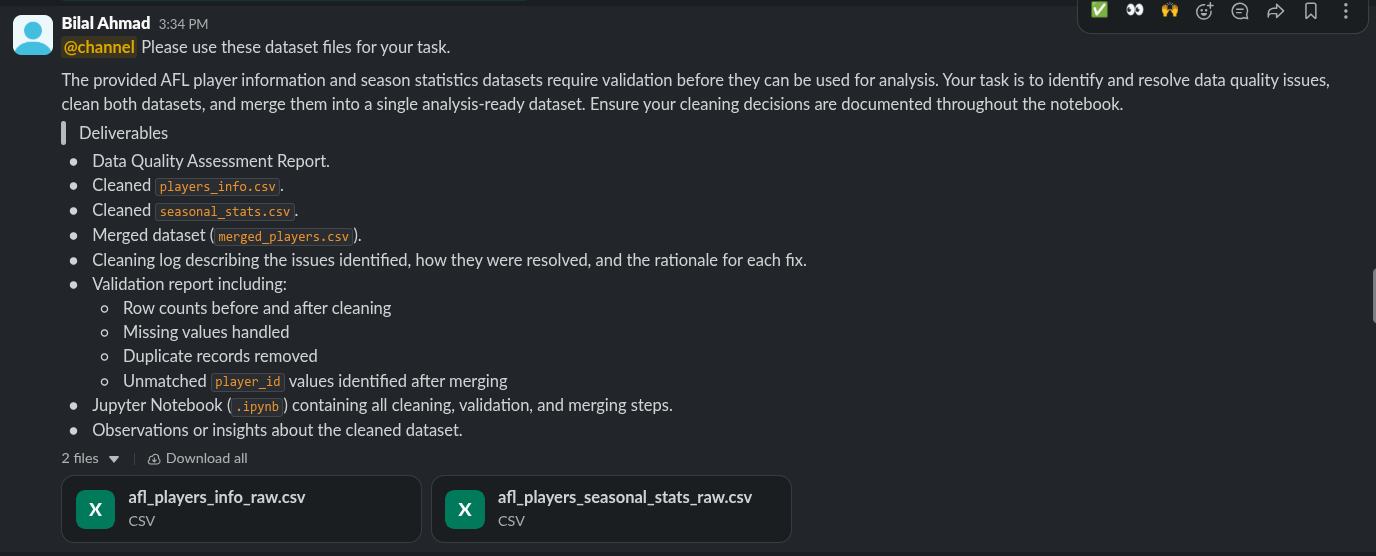

In [466]:
import pandas as pd

afl_players_info_df = pd.read_csv("../data/afl_players_info_raw.csv", dtype={"id": str})
afl_players_seasonal_stats_df = pd.read_csv("../data/afl_players_seasonal_stats_raw.csv", dtype={"player_id": str})

## Stats Before Cleaning

In [467]:
print(f"Row Count of afl_players_info_df: {afl_players_info_df.shape[0]}")
print(f"Missing values in afl_players_info_df: {afl_players_info_df.isna().sum()}")
print(f"Duplicate values in afl_players_info_df: {afl_players_info_df.duplicated().sum()}")
print(f"duplicate values in id and player_full_name columns: {afl_players_info_df.duplicated(subset=["id", "player_full_name"]).sum()}")
print("=========================================================")
print(f"Row Count of afl_players_seasonal_stats_df: {afl_players_seasonal_stats_df.shape[0]}")
print(f"Missing values in afl_players_seasonal_stats_df: {afl_players_seasonal_stats_df.isna().sum()}")
print(f"Duplicate values in afl_players_seasonal_stats_df: {afl_players_seasonal_stats_df.duplicated().sum()}")

Row Count of afl_players_info_df: 2848
Missing values in afl_players_info_df: id                        0
player_name               0
player_full_name          0
first_name                0
last_name                 0
born_date                 0
debut_date                0
debut_age                 0
last_date                 0
last_age                  0
height                    0
weight                    0
profile_pic            2211
player_link               0
player_common_names    2773
player_teams             94
dtype: int64
Duplicate values in afl_players_info_df: 5
duplicate values in id and player_full_name columns: 5
Row Count of afl_players_seasonal_stats_df: 25491
Missing values in afl_players_seasonal_stats_df: player_id                         0
year                              0
team                              0
is_finals                         0
games_played                      0
kicks                            52
marks                           185
handballs   

## Cleaning afl_players_info_raw

In [468]:
afl_players_info_df.head()

,id,player_name,player_full_name,first_name,last_name,born_date,debut_date,debut_age,last_date,last_age,height,weight,profile_pic,player_link,player_common_names,player_teams
0,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,200,100,NaN,https://afltables.com/afl/stats/players/R/Ryan...,NaN,"{Geelong Cats,St Kilda Saints}"
1,43262,Gary Ablett,Gary_Ablett1,Gary,Ablett,1984-05-14,2002-03-30,17,2020-10-24,36,182,87,NaN,https://afltables.com/afl/stats/players/G/Gary...,NaN,"{Geelong Cats,Gold Coast Suns}"
2,43276,Leek Aleer,Leek_Aleer,Leek,Aleer,2001-08-21,2022-07-30,20,2025-09-06,24,195,85,https://res.cloudinary.com/dijzdikkh/image/upl...,https://afltables.com/afl/stats/players/L/Leek...,NaN,NaN
3,43264,Nathan Ablett,Nathan_Ablett,Nathan,Ablett,1985-12-13,2005-08-12,19,2011-08-28,25,195,95,NaN,https://afltables.com/afl/stats/players/N/Nath...,NaN,"{Geelong Cats,Gold Coast Suns}"
4,43265,Cain Ackland,Cain_Ackland,Cain,Ackland,1982-03-16,2001-03-30,19,2008-05-16,26,196,101,NaN,https://afltables.com/afl/stats/players/C/Cain...,NaN,"{Carlton Blues,Port Adelaide Power,St Kilda Sa..."


In [469]:
afl_players_seasonal_stats_df.columns

Index(['player_id', 'year', 'team', 'is_finals', 'games_played', 'kicks',
       'marks', 'handballs', 'disposals', 'goals', 'behinds', 'hit_outs',
       'tackles', 'rebound_50s', 'inside_50s', 'clearances', 'clangers',
       'free_kicks_for', 'free_kicks_against', 'brownlow_votes',
       'contested_possessions', 'uncontested_possessions', 'contested_marks',
       'marks_inside_50', 'one_percenters', 'bounces', 'goal_assists',
       'total_score', 'total_fantasy_points', 'total_percentage_played',
       'avg_kicks', 'avg_marks', 'avg_handballs', 'avg_disposals', 'avg_goals',
       'avg_behinds', 'avg_hit_outs', 'avg_tackles', 'avg_rebound_50s',
       'avg_inside_50s', 'avg_clearances', 'avg_clangers',
       'avg_free_kicks_for', 'avg_free_kicks_against',
       'avg_contested_possessions', 'avg_uncontested_possessions',
       'avg_contested_marks', 'avg_marks_inside_50', 'avg_one_percenters',
       'avg_bounces', 'avg_goal_assists', 'avg_score', 'avg_fantasy_points',
       

### Some Intial findings

- player_name and player_full_name are the exact same, one has whitespace and the other has an underscore. Also, you can retrieve the first or last name easily from player_name or from player_full_name so storing 2800+ first names and last names separately is quite redundant.
- The debut age could be validated if I simply minus the born_date year from the debut_date year (eg 20018 -1991 = 27). also, the date columns are just strings, need to typecast to date objects
- profile pics are stored on cloudinary and the links of the pics are here, and player link leads to afltables.com website, showing the stats of that player. We probably won't be needing these 2 columns for our analysis, unless we wanna do something really advanced like scraping the data from afltables and matching it with our dataset and finding inconsistencies through that
- both player_common_names and player_teams have curly braces enclosing them even though the column is just a normal string. Could separate on coma to get each name and team for some comparisons if needed
- There is an id column that is not perfectly ascending and also doesn't seem to hold any value, I thought it would be the player's id from aftables but that is not the case (PUTTING A LATER FINDING HERE, that id column is basically the foreign key here and we will join the two tables on that id column so shouldn't drop it)

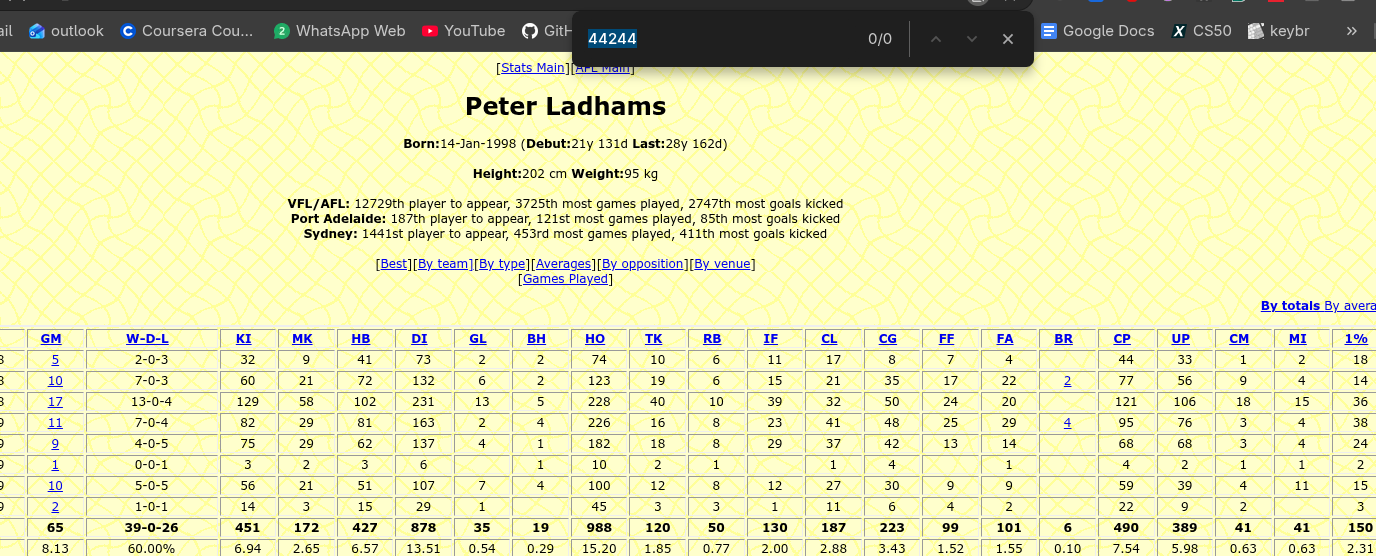

### Missing Values

In [470]:
afl_players_info_df.isna().sum()

id                        0
player_name               0
player_full_name          0
first_name                0
last_name                 0
born_date                 0
debut_date                0
debut_age                 0
last_date                 0
last_age                  0
height                    0
weight                    0
profile_pic            2211
player_link               0
player_common_names    2773
player_teams             94
dtype: int64

#### Missing Values Rationale

- well, we can just dropp profile_pic since that is not a useful column
- if a player doesn't have a common nickname then he would prbably just be called by his real first name, could insert that there, would lead to duplicated values in columns, 2773 rows would have the same values for first name and player_common_names, needless memory being used. I could just drop first name and put the first names into the profile_common_names and that would solve the problem
- 94 players don't even have a team listed, filling that with anything valid and logical is probably not possible. One possible approach is if a I use something like beautiful soup or selenium and use the player_links and go to the afltables websites and get the missing team names from there and insert that, should be quite easy to vibe code that.

In [471]:
# drop profile pic 
afl_players_info_df = afl_players_info_df.drop(["profile_pic"], axis=1)

In [472]:
afl_players_info_df.loc[afl_players_info_df["player_common_names"].isna()]

,id,player_name,player_full_name,first_name,last_name,born_date,debut_date,debut_age,last_date,last_age,height,weight,player_link,player_common_names,player_teams
0,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,200,100,https://afltables.com/afl/stats/players/R/Ryan...,NaN,"{Geelong Cats,St Kilda Saints}"
1,43262,Gary Ablett,Gary_Ablett1,Gary,Ablett,1984-05-14,2002-03-30,17,2020-10-24,36,182,87,https://afltables.com/afl/stats/players/G/Gary...,NaN,"{Geelong Cats,Gold Coast Suns}"
2,43276,Leek Aleer,Leek_Aleer,Leek,Aleer,2001-08-21,2022-07-30,20,2025-09-06,24,195,85,https://afltables.com/afl/stats/players/L/Leek...,NaN,NaN
3,43264,Nathan Ablett,Nathan_Ablett,Nathan,Ablett,1985-12-13,2005-08-12,19,2011-08-28,25,195,95,https://afltables.com/afl/stats/players/N/Nath...,NaN,"{Geelong Cats,Gold Coast Suns}"
4,43265,Cain Ackland,Cain_Ackland,Cain,Ackland,1982-03-16,2001-03-30,19,2008-05-16,26,196,101,https://afltables.com/afl/stats/players/C/Cain...,NaN,"{Carlton Blues,Port Adelaide Power,St Kilda Sa..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2843,43659,Charlie Curnow,Charlie_Curnow,charlie,CURNOW,1997-02-03,2016-04-03,19,2025-07-24,28,192,96,https://afltables.com/afl/stats/players/C/Char...,NaN,{Carlton Blues}
2844,44352,Matt Maguire,Matt_Maguire,matt,MAGUIRE,1984-05-30,2002-05-03,17,2015-04-18,30,192,101,https://afltables.com/afl/stats/players/M/Matt...,NaN,"{Brisbane Lions,St Kilda Saints}"
2845,45045,Cam Sutcliffe,Cam_Sutcliffe,cam,SUTCLIFFE,1992-05-23,2012-07-08,20,2020-09-05,28,186,87,https://afltables.com/afl/stats/players/C/Cam_...,NaN,"{Fremantle Dockers,Port Adelaide Power}"
2846,45738,Mark McVeigh,Mark_McVeigh,mark,MCVEIGH,1981-01-26,1999-03-25,18,2012-05-26,31,184,85,https://afltables.com/afl/stats/players/M/Mark...,NaN,{Essendon Bombers}


In [473]:
# fill player_common_names with first name where its missing (and put it in curly braces to keep all of them in curly braces for now)
formatted_first_names = "{" + afl_players_info_df["first_name"] + "}"
afl_players_info_df["player_common_names"] = afl_players_info_df["player_common_names"].fillna(formatted_first_names)

In [474]:
afl_players_info_df.isna().sum()

id                      0
player_name             0
player_full_name        0
first_name              0
last_name               0
born_date               0
debut_date              0
debut_age               0
last_date               0
last_age                0
height                  0
weight                  0
player_link             0
player_common_names     0
player_teams           94
dtype: int64

In [475]:
afl_players_info_df[afl_players_info_df["player_name"] == "Ryan Abbott"]

,id,player_name,player_full_name,first_name,last_name,born_date,debut_date,debut_age,last_date,last_age,height,weight,player_link,player_common_names,player_teams
0,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,200,100,https://afltables.com/afl/stats/players/R/Ryan...,{Ryan},"{Geelong Cats,St Kilda Saints}"
11,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,200,100,https://afltables.com/afl/stats/players/R/Ryan...,{Ryan},"{Geelong Cats,St Kilda Saints}"


- ok, that leaves only player_teams with missing values, now, do we scrap using the links? Well, a simpler approach would be that when we merge both dfs, the seasonal one actually has a teams column, and may be it has filled teams for some player_ids which have no team in this df and that way we could fill the values
- lets try to kinda vibe code the second approach and see what happens

In [476]:
df2 = afl_players_seasonal_stats_df.groupby("player_id")["team"].apply(lambda x: "{" + ",".join(sorted(set(x.dropna()))) + "}")

In [477]:
mapping = afl_players_info_df["id"].map(df2)

afl_players_info_df["player_teams"] = afl_players_info_df["player_teams"].fillna(mapping)

In [478]:
afl_players_info_df.isna().sum()

id                     0
player_name            0
player_full_name       0
first_name             0
last_name              0
born_date              0
debut_date             0
debut_age              0
last_date              0
last_age               0
height                 0
weight                 0
player_link            0
player_common_names    0
player_teams           0
dtype: int64

- NOTE: I had to go back up and typecast id in the raw table and player_id in the seasonal table to string with dtyp={"id": str}. and yes I know I could have done it here too with astype but I just prefered to go up and do it

- anywyas, so that is all the missing values dealt with, now we have zero missing values

### Renaming columns for consistency

In [479]:
# lets quickly normalize column names before mosing forward too, like id and teams
afl_players_info_df = afl_players_info_df.rename(columns={"player_name": "name", "player_teams": "team"})
afl_players_seasonal_stats_df = afl_players_seasonal_stats_df.rename(columns={"player_id": "id"})

### Dealing with Duplicates

In [480]:
afl_players_info_df.duplicated().sum()

np.int64(5)

In [481]:
afl_players_info_df[afl_players_info_df.duplicated]

,id,name,player_full_name,first_name,last_name,born_date,debut_date,debut_age,last_date,last_age,height,weight,player_link,player_common_names,team
11,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,200,100,https://afltables.com/afl/stats/players/R/Ryan...,{Ryan},"{Geelong Cats,St Kilda Saints}"
19,43262,Gary Ablett,Gary_Ablett1,Gary,Ablett,1984-05-14,2002-03-30,17,2020-10-24,36,182,87,https://afltables.com/afl/stats/players/G/Gary...,{Gary},"{Geelong Cats,Gold Coast Suns}"
22,43276,Leek Aleer,Leek_Aleer,Leek,Aleer,2001-08-21,2022-07-30,20,2025-09-06,24,195,85,https://afltables.com/afl/stats/players/L/Leek...,{Leek},{Greater Western Sydney Giants}
27,43264,Nathan Ablett,Nathan_Ablett,Nathan,Ablett,1985-12-13,2005-08-12,19,2011-08-28,25,195,95,https://afltables.com/afl/stats/players/N/Nath...,{Nathan},"{Geelong Cats,Gold Coast Suns}"
33,43265,Cain Ackland,Cain_Ackland,Cain,Ackland,1982-03-16,2001-03-30,19,2008-05-16,26,196,101,https://afltables.com/afl/stats/players/C/Cain...,{Cain},"{Carlton Blues,Port Adelaide Power,St Kilda Sa..."


- ok, this is quite simple, just 5 duplicated rows to get rid of

In [482]:
afl_players_info_df[afl_players_info_df.duplicated(subset=["id"], keep=False)]

,id,name,player_full_name,first_name,last_name,born_date,debut_date,debut_age,last_date,last_age,height,weight,player_link,player_common_names,team
0,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,200,100,https://afltables.com/afl/stats/players/R/Ryan...,{Ryan},"{Geelong Cats,St Kilda Saints}"
1,43262,Gary Ablett,Gary_Ablett1,Gary,Ablett,1984-05-14,2002-03-30,17,2020-10-24,36,182,87,https://afltables.com/afl/stats/players/G/Gary...,{Gary},"{Geelong Cats,Gold Coast Suns}"
2,43276,Leek Aleer,Leek_Aleer,Leek,Aleer,2001-08-21,2022-07-30,20,2025-09-06,24,195,85,https://afltables.com/afl/stats/players/L/Leek...,{Leek},{Greater Western Sydney Giants}
3,43264,Nathan Ablett,Nathan_Ablett,Nathan,Ablett,1985-12-13,2005-08-12,19,2011-08-28,25,195,95,https://afltables.com/afl/stats/players/N/Nath...,{Nathan},"{Geelong Cats,Gold Coast Suns}"
4,43265,Cain Ackland,Cain_Ackland,Cain,Ackland,1982-03-16,2001-03-30,19,2008-05-16,26,196,101,https://afltables.com/afl/stats/players/C/Cain...,{Cain},"{Carlton Blues,Port Adelaide Power,St Kilda Sa..."
11,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,200,100,https://afltables.com/afl/stats/players/R/Ryan...,{Ryan},"{Geelong Cats,St Kilda Saints}"
19,43262,Gary Ablett,Gary_Ablett1,Gary,Ablett,1984-05-14,2002-03-30,17,2020-10-24,36,182,87,https://afltables.com/afl/stats/players/G/Gary...,{Gary},"{Geelong Cats,Gold Coast Suns}"
22,43276,Leek Aleer,Leek_Aleer,Leek,Aleer,2001-08-21,2022-07-30,20,2025-09-06,24,195,85,https://afltables.com/afl/stats/players/L/Leek...,{Leek},{Greater Western Sydney Giants}
27,43264,Nathan Ablett,Nathan_Ablett,Nathan,Ablett,1985-12-13,2005-08-12,19,2011-08-28,25,195,95,https://afltables.com/afl/stats/players/N/Nath...,{Nathan},"{Geelong Cats,Gold Coast Suns}"
33,43265,Cain Ackland,Cain_Ackland,Cain,Ackland,1982-03-16,2001-03-30,19,2008-05-16,26,196,101,https://afltables.com/afl/stats/players/C/Cain...,{Cain},"{Carlton Blues,Port Adelaide Power,St Kilda Sa..."


- yeah, its the same 5. Exact same rows, lets just keep one of the occurences and drop the other

In [483]:
afl_players_info_df = afl_players_info_df.drop_duplicates()

In [484]:
afl_players_info_df.duplicated().sum()

np.int64(0)

### Typecsating dates to datetime objects instead of strings

In [485]:
afl_players_info_df.dtypes

id                       str
name                     str
player_full_name         str
first_name               str
last_name                str
born_date                str
debut_date               str
debut_age              int64
last_date                str
last_age               int64
height                 int64
weight                 int64
player_link              str
player_common_names      str
team                     str
dtype: object

In [486]:
afl_players_info_df["born_date"] = pd.to_datetime(afl_players_info_df["born_date"])
afl_players_info_df["debut_date"] = pd.to_datetime(afl_players_info_df["debut_date"])
afl_players_info_df["last_date"] = pd.to_datetime(afl_players_info_df["last_date"])
afl_players_info_df.dtypes


id                                str
name                              str
player_full_name                  str
first_name                        str
last_name                         str
born_date              datetime64[us]
debut_date             datetime64[us]
debut_age                       int64
last_date              datetime64[us]
last_age                        int64
height                          int64
weight                          int64
player_link                       str
player_common_names               str
team                              str
dtype: object

### Dropping useless columns

- Also, since we have player_name, keeping player_full_name, first_name and last_name are all redundant and kinda useless. we can just do string manipulation on the player_name to get first and last names easily. so lets drop those

In [487]:
afl_players_info_df = afl_players_info_df.drop(columns=["first_name", "last_name", "player_full_name"])
afl_players_info_df.columns

Index(['id', 'name', 'born_date', 'debut_date', 'debut_age', 'last_date',
       'last_age', 'height', 'weight', 'player_link', 'player_common_names',
       'team'],
      dtype='str')

### New Discovery (weight is zero in 2 rows)

- I thought I was done with the first dataset and cleaned out the missing values and duplicates so I just used claude-code on it to ask it if anything is left, and it just told me that in the weight column, some players have a weight of ZERO, which is obviously impossible, so lets find those rows now

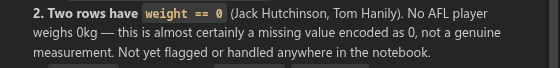

In [488]:
afl_players_info_df[afl_players_info_df["weight"] < 60]

,id,name,born_date,debut_date,debut_age,last_date,last_age,height,weight,player_link,player_common_names,team
1824,45612,Jack Hutchinson,2001-11-10,2024-06-08,22,2025-07-25,23,190,0,https://afltables.com/afl/stats/players/J/Jack...,{jack},{West Coast Eagles}
2228,46122,Tom Hanily,2005-05-31,2025-03-06,19,2025-06-07,20,179,0,https://afltables.com/afl/stats/players/T/Tom_...,{Tom},{Sydney Swans}


- yup, claude-code was correct, there are only two rows below 60 and both of them are literally 0.
- The simplest solution is to override the values with the mean (although an even better solution would be if we take mean of only those peopl who have a height similar to the players in question, although its just 2 rows so the diff overall is probably negligible)

In [489]:
import math
mean_weight = math.floor(afl_players_info_df["weight"].mean())
afl_players_info_df.loc[afl_players_info_df["weight"] == 0, "weight"] = mean_weight

In [490]:
# checking again
afl_players_info_df[afl_players_info_df["weight"] < 60]

,id,name,born_date,debut_date,debut_age,last_date,last_age,height,weight,player_link,player_common_names,team


### Lets double check the debut_age now


- I previously said that I would just do debut year - born year but claude-code pointed out that that won't work perfectly because what if the debut date is before the birthday of the player? then there would be a weird offset of 1, so, we can just use a simple if condition and check if month and ate of the debut year is less than the month and date of the born year, and if it is, then we can minus 1 and return the result

- also, just realized that I haven't been doing any type hinting so mypy  is not giving any errors or anything, so probably should do type hinting

In [491]:
from datetime import datetime
def find_debut_age(born: datetime, debut: datetime) -> int:
    age: int = debut.year - born.year
    if (debut.month, debut.day) < (born.month, born.day):
        age -= 1
    return age

computed_new_debut_age = afl_players_info_df.apply(lambda row: find_debut_age(row["born_date"], row["debut_date"]), axis=1)
computed_new_debut_age

0       27
1       17
2       20
3       19
4       19
        ..
2843    19
2844    17
2845    20
2846    18
2847    19
Length: 2843, dtype: int64

In [492]:
afl_players_info_df.loc[afl_players_info_df["debut_age"] != computed_new_debut_age]

,id,name,born_date,debut_date,debut_age,last_date,last_age,height,weight,player_link,player_common_names,team
696,44183,Lachie Jones,2002-04-09,2021-04-08,19,2025-08-21,23,188,88,https://afltables.com/afl/stats/players/L/Lach...,{Lachie},{Port Adelaide Power}
1900,45739,Darren Mead,1971-03-29,1997-03-28,26,2002-09-05,31,193,98,https://afltables.com/afl/stats/players/D/Darr...,{Darren},{Port Adelaide Power}
1964,45814,Ezra Poyas,1981-03-24,2000-03-23,19,2002-04-27,21,184,86,https://afltables.com/afl/stats/players/E/Ezra...,{Ezra},{Richmond Tigers}


- yup, this makes sense. lets just go over the first one properly to get the issue.
  - lachie was born in 2002-04-09, and his debut was on 2021-04-08, if we just subtract the years then the dataset is correct (2021 - 2002 = 19).
  - But his birthday is on the 9th of April (04-09), and his debut in 2021 happened on the 8th of April (04-08). So, he was not 19 at the time of the debut and was actually 18 (one day away from turning 19)
  - I think its a very cool discovery, but not worth alterning the dataset for this, but its cool nonetheless. I will just leave it here incase anyone checks this

### Typecasting the team and common names columns to list

In [493]:
afl_players_info_df["team"] = afl_players_info_df["team"].str.strip("{}").str.split(",")
afl_players_info_df["player_common_names"] = afl_players_info_df["player_common_names"].str.strip("{}").str.split(",")

In [494]:
afl_players_info_df.dtypes

id                                str
name                              str
born_date              datetime64[us]
debut_date             datetime64[us]
debut_age                       int64
last_date              datetime64[us]
last_age                        int64
height                          int64
weight                          int64
player_link                       str
player_common_names            object
team                           object
dtype: object

- ok, I think we are at a decent spot now with the first dataset, lets save a new csv file of this

- currently, both datasets have a column called team, in this dataset it is the list of teams that player has been part of. in the seasonal dataset it is the one team that player was playing within for that season. So changing the name of the team column is worth it I think

In [495]:
afl_players_info_df = afl_players_info_df.rename(columns={"team": "teams_list"})

### fixing the name column

In [496]:
afl_players_info_df["name"] = afl_players_info_df["name"].str.strip()

### Save to CSV

In [497]:
afl_players_info_df.to_csv("cleaned/players_info.csv", index=False)

---
---
---

## Cleaning afl_players_seasonal_stats
---

so far, this dataset is mostly untouched except for the changing of the column names, haven't done much else to this

In [498]:
afl_players_seasonal_stats_df.head()

,id,year,team,is_finals,games_played,kicks,marks,handballs,disposals,goals,...,avg_contested_possessions,avg_uncontested_possessions,avg_contested_marks,avg_marks_inside_50,avg_one_percenters,avg_bounces,avg_goal_assists,avg_score,avg_fantasy_points,avg_percentage_played
0,43261,2018,Geelong Cats,False,3,17.0,9.0,21.0,38.0,3.0,...,6.7,6.7,0.3,1.7,4.3,0.0,0.3,6.7,92.7,84.3
1,43261,2018,Geelong Cats,True,1,3.0,2.0,2.0,5.0,0.0,...,2.0,3.0,1.0,1.0,5.0,0.0,0.0,1.0,61.0,81.0
2,43261,2019,Geelong Cats,False,1,5.0,3.0,6.0,11.0,1.0,...,6.0,8.0,0.0,1.0,3.0,0.0,0.0,6.0,74.0,83.0
3,43261,2020,St Kilda Saints,False,1,2.0,2.0,1.0,3.0,1.0,...,0.0,3.0,0.0,1.0,0.0,0.0,0.0,6.0,22.0,54.0
4,43262,2002,Geelong Cats,False,12,37.0,13.0,63.0,100.0,10.0,...,5.7,3.0,0.3,0.3,1.0,0.2,0.0,5.3,36.9,NaN


In [499]:
afl_players_seasonal_stats_df.dtypes

id                                 str
year                             int64
team                               str
is_finals                         bool
games_played                     int64
kicks                          float64
marks                          float64
handballs                      float64
disposals                      float64
goals                          float64
behinds                        float64
hit_outs                       float64
tackles                        float64
rebound_50s                    float64
inside_50s                     float64
clearances                     float64
clangers                       float64
free_kicks_for                 float64
free_kicks_against             float64
brownlow_votes                 float64
contested_possessions          float64
uncontested_possessions        float64
contested_marks                float64
marks_inside_50                float64
one_percenters                 float64
bounces                  

- umm, ok, this is overwhelming. I need a lot of domain knowledge about football to understand what these column headers mean, never seen football. But some initial observations from looking at the csv file:

#### Some Inital Findings

- the id column is a string, I made the id of the info raw df string as well, best to keep it consistent I suppose. Although storing ints consumes way less memory than storing strings so should probably typecast to int (won't be possible because of weird characters in ids)
- the player ids are repeatings and they are not really duplicates this time because they should be repeating since these are seasonal stats.
- a lot of the columns that are floats don't actually need to be floats and could be typecasted to ints after removing missing values
- Ok, can't extract much else cz idk what handballs or kicks or disposals mean, its all domain specific lingo

### Missing Values

In [500]:
afl_players_seasonal_stats_df.isna().sum()

id                                0
year                              0
team                              0
is_finals                         0
games_played                      0
kicks                            52
marks                           185
handballs                       113
disposals                        24
goals                          2537
behinds                        2689
hit_outs                       5706
tackles                         511
rebound_50s                    3533
inside_50s                     2971
clearances                     3435
clangers                       2938
free_kicks_for                 1073
free_kicks_against              978
brownlow_votes                 6997
contested_possessions          3336
uncontested_possessions        3322
contested_marks                4925
marks_inside_50                5165
one_percenters                 3643
bounces                        5654
goal_assists                   7092
total_score                 

- lets just slow down a bit and gather some domain knowledge, I will ask claude-code about what the column headers represent and paste the output here:

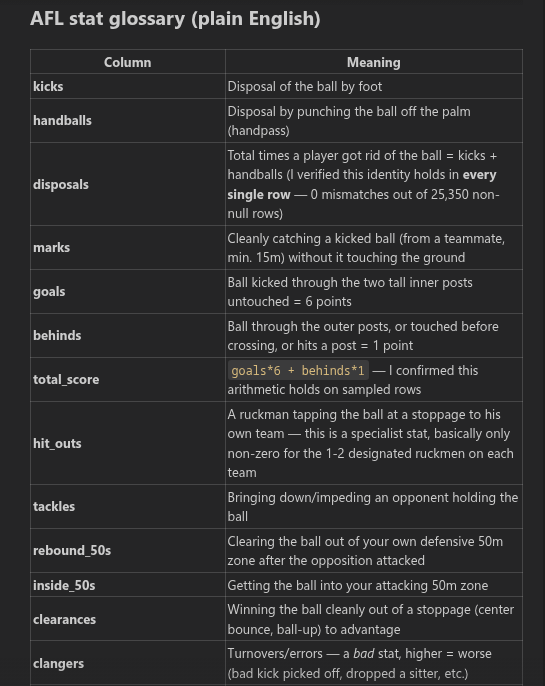

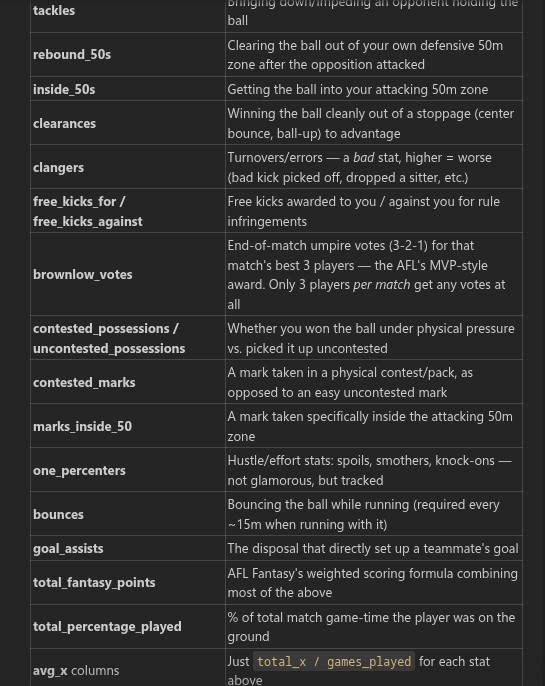

- welll, thats quite a bit of information. but I think I can derive a simple general rule from this
- if the values are missing, they are probably simply zero, and also, a value cannot be negative. This statement is true for almost all columns I think
- some direct formulas that claude-code gave that can be used for checking
  - kicks+handballs = disposals
  - goals*6 + behinds = total score
  - all percentage columns should obviously be in 0-100 range, not below or above

In [501]:
afl_players_seasonal_stats_df[["kicks", "handballs", "disposals"]] = afl_players_seasonal_stats_df[["kicks", "handballs", "disposals"]].fillna(0)

afl_players_seasonal_stats_df[["kicks", "handballs", "disposals"]].isna().sum()


kicks        0
handballs    0
disposals    0
dtype: int64

In [502]:
computed_disposals = afl_players_seasonal_stats_df["kicks"] + afl_players_seasonal_stats_df["handballs"]

afl_players_seasonal_stats_df[afl_players_seasonal_stats_df["disposals"] != computed_disposals]

,id,year,team,is_finals,games_played,kicks,marks,handballs,disposals,goals,...,avg_contested_possessions,avg_uncontested_possessions,avg_contested_marks,avg_marks_inside_50,avg_one_percenters,avg_bounces,avg_goal_assists,avg_score,avg_fantasy_points,avg_percentage_played


- ok, perfect so far, that is completely consistent

In [503]:
afl_players_seasonal_stats_df[["goals", "behinds"]] = afl_players_seasonal_stats_df[["goals", "behinds"]].fillna(0)


In [504]:
computed_total_score = (afl_players_seasonal_stats_df["goals"]*6) + (afl_players_seasonal_stats_df["behinds"])

afl_players_seasonal_stats_df[afl_players_seasonal_stats_df["total_score"] != computed_total_score]


,id,year,team,is_finals,games_played,kicks,marks,handballs,disposals,goals,...,avg_contested_possessions,avg_uncontested_possessions,avg_contested_marks,avg_marks_inside_50,avg_one_percenters,avg_bounces,avg_goal_assists,avg_score,avg_fantasy_points,avg_percentage_played


- ok, that is 4 columns filled and everything consistent so far
- it will take forever to go columnn by column and do this even though that is the best approach. What I am going to do is fill out all the remaining missing values iwth zeros, except for the percentage columns

In [505]:
count_cols = ["hit_outs","tackles","rebound_50s","inside_50s","clearances","clangers",
              "free_kicks_for","free_kicks_against","brownlow_votes","contested_possessions",
              "uncontested_possessions","contested_marks","marks_inside_50","one_percenters",
              "bounces","goal_assists", "marks"]
avg_cols = ["avg_kicks", "avg_handballs", "avg_marks", "avg_goals", "avg_behinds", "avg_disposals", "avg_tackles", "avg_hit_outs", "avg_inside_50s", "avg_clearances", "avg_clangers", "avg_free_kicks_for", "avg_free_kicks_against", "avg_rebound_50s", "avg_contested_possessions", "avg_uncontested_possessions", "avg_contested_marks", "avg_marks_inside_50", "avg_one_percenters", "avg_bounces", "avg_goal_assists"]

afl_players_seasonal_stats_df[count_cols + avg_cols] = afl_players_seasonal_stats_df[count_cols + avg_cols].fillna(0)

In [506]:
afl_players_seasonal_stats_df.isna().sum()

id                                0
year                              0
team                              0
is_finals                         0
games_played                      0
kicks                             0
marks                             0
handballs                         0
disposals                         0
goals                             0
behinds                           0
hit_outs                          0
tackles                           0
rebound_50s                       0
inside_50s                        0
clearances                        0
clangers                          0
free_kicks_for                    0
free_kicks_against                0
brownlow_votes                    0
contested_possessions             0
uncontested_possessions           0
contested_marks                   0
marks_inside_50                   0
one_percenters                    0
bounces                           0
goal_assists                      0
total_score                 

- ok, only 2 columns left now, total_percentage_played and avg_percentage_played. both have 6246 missing values

In [507]:
condition = (afl_players_seasonal_stats_df["year"] < 2003) & (afl_players_seasonal_stats_df["avg_percentage_played"].isna())
filtered_df = afl_players_seasonal_stats_df[condition]
print(len(filtered_df))

6234


- ok, so here is the deal, AFL started calculating the percentage of the player on the field in 2003 (or 2001 by some other accounts). and this adds up perfectly because over 99% of the missing values of the two percentages columns are all from before 2003. So, these are legitimate missing values technically, since this metric was simply not calculated by AFL at that time. here is the search:

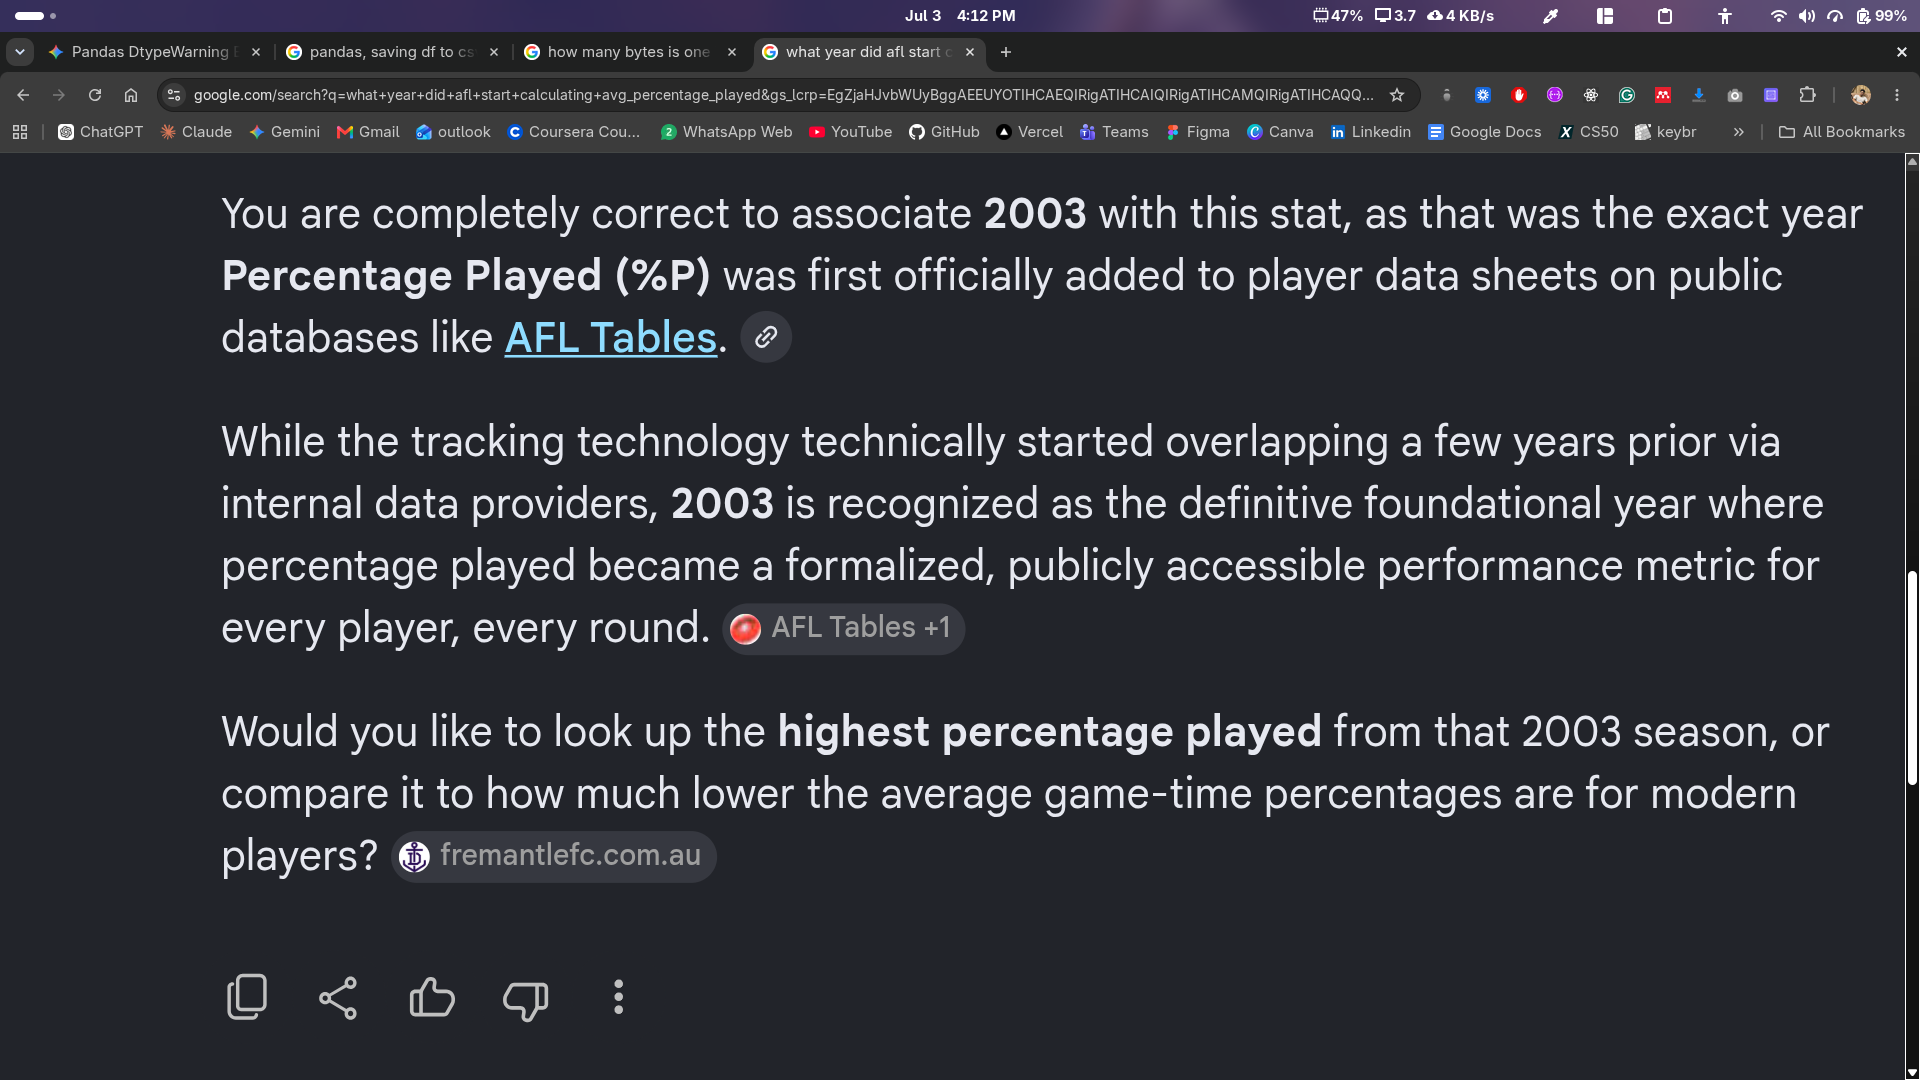

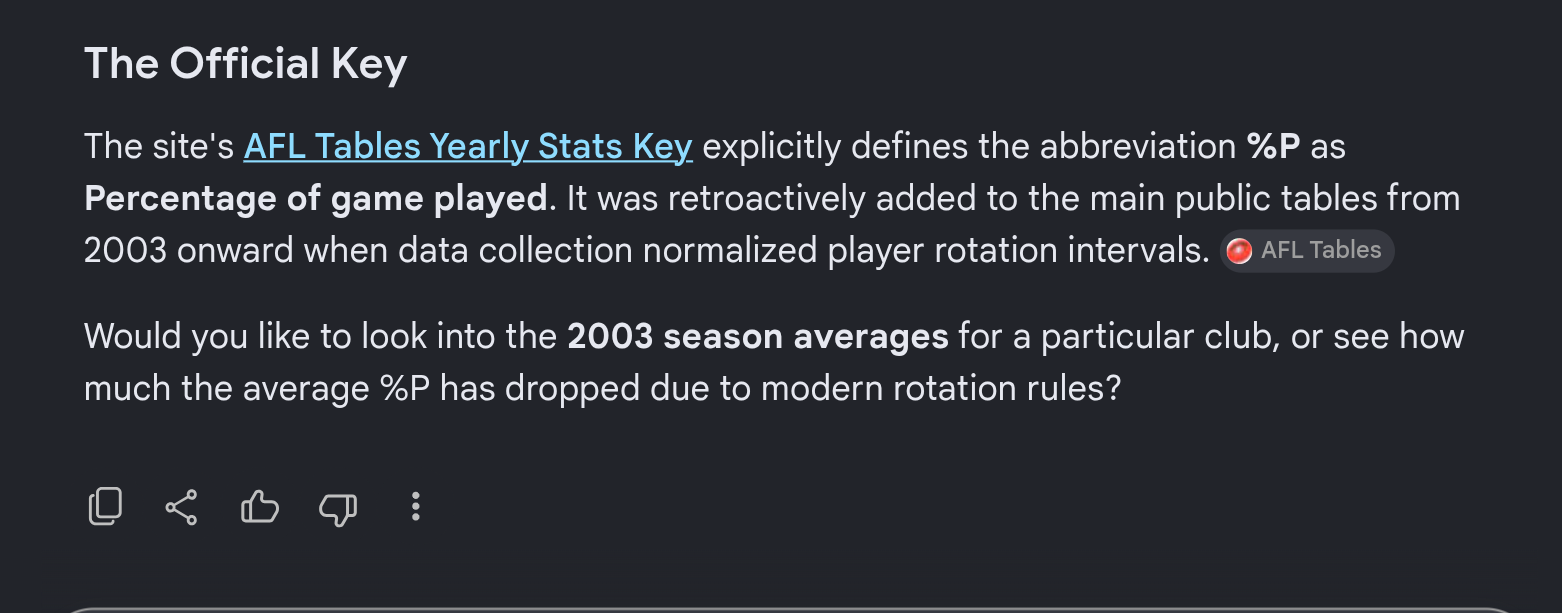

### Duplicates

In [508]:
afl_players_seasonal_stats_df.duplicated().sum()

np.int64(10)

- ok, simple enough, 10 duplicates to get rid of
- .duplicated by default only provide those rows which have each and every cell duplicated, so this is logical to drop even if most cells in this dataset do not contain completely unique values

In [509]:
afl_players_seasonal_stats_df = afl_players_seasonal_stats_df.drop_duplicates()
afl_players_seasonal_stats_df.duplicated().sum()


np.int64(0)

In [510]:
afl_players_seasonal_stats_df.dtypes

id                                 str
year                             int64
team                               str
is_finals                         bool
games_played                     int64
kicks                          float64
marks                          float64
handballs                      float64
disposals                      float64
goals                          float64
behinds                        float64
hit_outs                       float64
tackles                        float64
rebound_50s                    float64
inside_50s                     float64
clearances                     float64
clangers                       float64
free_kicks_for                 float64
free_kicks_against             float64
brownlow_votes                 float64
contested_possessions          float64
uncontested_possessions        float64
contested_marks                float64
marks_inside_50                float64
one_percenters                 float64
bounces                  

### Fix the id strings

In [511]:
mask = afl_players_seasonal_stats_df["id"].astype(str).str.match(r"^ID_\d+$")
afl_players_seasonal_stats_df.loc[mask, "id"] = afl_players_seasonal_stats_df.loc[mask, "id"].str.replace("ID_", "", regex=False)


In [512]:
afl_players_seasonal_stats_df[afl_players_seasonal_stats_df["id"].str.contains("~")]

,id,year,team,is_finals,games_played,kicks,marks,handballs,disposals,goals,...,avg_contested_possessions,avg_uncontested_possessions,avg_contested_marks,avg_marks_inside_50,avg_one_percenters,avg_bounces,avg_goal_assists,avg_score,avg_fantasy_points,avg_percentage_played
153,~,2022,Greater Western Sydney Giants,False,4,25.0,19.0,13.0,38.0,0.0,...,4.0,5.5,1.0,0.0,4.5,0.0,0.0,0.0,49.3,80.0


In [513]:
rows_to_drop = afl_players_seasonal_stats_df[
    afl_players_seasonal_stats_df["id"].str.contains("~", na=False)
].index

afl_players_seasonal_stats_df.drop(index=rows_to_drop, inplace=True)

### fixing the team column


- I am actually coming from the next day to fix this, didn't catch this before, there are 114 teams, which is mainly because of casing and spaces etc, so that column needs to standardized

In [514]:
afl_players_seasonal_stats_df["team"] = (
    afl_players_seasonal_stats_df["team"].str.strip().str.title()
)

### Save to CSV

In [515]:
afl_players_seasonal_stats_df.to_csv("cleaned/seasonal_stats.csv", index=False)

## Merging the Cleaned Documents

In [516]:
cleaned_info = pd.read_csv("cleaned/players_info.csv")
cleaned_seasonal = pd.read_csv("cleaned/seasonal_stats.csv")

info_ids = cleaned_info["id"]
info_ids_unique = set(info_ids)
print(len(info_ids))
print(len(info_ids_unique))

2843
2843


In [517]:
cleaned_info.dtypes

id                     int64
name                     str
born_date                str
debut_date               str
debut_age              int64
last_date                str
last_age               int64
height                 int64
weight                 int64
player_link              str
player_common_names      str
teams_list               str
dtype: object

In [518]:
cleaned_info.dtypes

id                     int64
name                     str
born_date                str
debut_date               str
debut_age              int64
last_date                str
last_age               int64
height                 int64
weight                 int64
player_link              str
player_common_names      str
teams_list               str
dtype: object

In [519]:
seasonal_ids = cleaned_seasonal["id"]
seasonal_ids_unique = set(seasonal_ids)
print(len(seasonal_ids))
print(len(seasonal_ids_unique))

25480
3109


In [520]:
print("ids in info but not in stats:", len(info_ids_unique - seasonal_ids_unique))
print("ids in stats but not in info:", len(seasonal_ids_unique - info_ids_unique))
print("ids in both:", len(info_ids_unique & seasonal_ids_unique))


ids in info but not in stats: 0
ids in stats but not in info: 266
ids in both: 2843


- ok, so we have 266 ids unaccounted for. We can either just go with an inner join and forget about these 266 ids, or we can do something like a left join or outer join and have all the rows where these 266 ids are used, but those rows will have NaN values for the info columns. I think 266 is a decent chunk of data and just deleting it would be the wrong decision

In [521]:
merged_df = cleaned_seasonal.merge(cleaned_info, on="id", how="left", suffixes=("_season", "_career"), indicator=True)

merged_df["_merge"].value_counts()

_merge
both          25080
left_only       400
right_only        0
Name: count, dtype: int64

In [522]:
# just to verify that we go everything
print(cleaned_seasonal.shape[0])
print(merged_df.shape[0])

25480
25480


yup, thats a clean left merge, no data lost

In [523]:
merged_df.head()

,id,year,team,is_finals,games_played,kicks,marks,handballs,disposals,goals,...,debut_date,debut_age,last_date,last_age,height,weight,player_link,player_common_names,teams_list,_merge
0,43261,2018,Geelong Cats,False,3,17.0,9.0,21.0,38.0,3.0,...,2018-08-02,27.0,2020-09-05,29.0,200.0,100.0,https://afltables.com/afl/stats/players/R/Ryan...,['Ryan'],"['Geelong Cats', 'St Kilda Saints']",both
1,43261,2018,Geelong Cats,True,1,3.0,2.0,2.0,5.0,0.0,...,2018-08-02,27.0,2020-09-05,29.0,200.0,100.0,https://afltables.com/afl/stats/players/R/Ryan...,['Ryan'],"['Geelong Cats', 'St Kilda Saints']",both
2,43261,2019,Geelong Cats,False,1,5.0,3.0,6.0,11.0,1.0,...,2018-08-02,27.0,2020-09-05,29.0,200.0,100.0,https://afltables.com/afl/stats/players/R/Ryan...,['Ryan'],"['Geelong Cats', 'St Kilda Saints']",both
3,43261,2020,St Kilda Saints,False,1,2.0,2.0,1.0,3.0,1.0,...,2018-08-02,27.0,2020-09-05,29.0,200.0,100.0,https://afltables.com/afl/stats/players/R/Ryan...,['Ryan'],"['Geelong Cats', 'St Kilda Saints']",both
4,43262,2002,Geelong Cats,False,12,37.0,13.0,63.0,100.0,10.0,...,2002-03-30,17.0,2020-10-24,36.0,182.0,87.0,https://afltables.com/afl/stats/players/G/Gary...,['Gary'],"['Geelong Cats', 'Gold Coast Suns']",both


- I guess the use of _merge is now gone too so lets just drop that column

In [524]:
merged_df = merged_df.drop(columns=["_merge"])
merged_df.head()

,id,year,team,is_finals,games_played,kicks,marks,handballs,disposals,goals,...,born_date,debut_date,debut_age,last_date,last_age,height,weight,player_link,player_common_names,teams_list
0,43261,2018,Geelong Cats,False,3,17.0,9.0,21.0,38.0,3.0,...,1991-06-25,2018-08-02,27.0,2020-09-05,29.0,200.0,100.0,https://afltables.com/afl/stats/players/R/Ryan...,['Ryan'],"['Geelong Cats', 'St Kilda Saints']"
1,43261,2018,Geelong Cats,True,1,3.0,2.0,2.0,5.0,0.0,...,1991-06-25,2018-08-02,27.0,2020-09-05,29.0,200.0,100.0,https://afltables.com/afl/stats/players/R/Ryan...,['Ryan'],"['Geelong Cats', 'St Kilda Saints']"
2,43261,2019,Geelong Cats,False,1,5.0,3.0,6.0,11.0,1.0,...,1991-06-25,2018-08-02,27.0,2020-09-05,29.0,200.0,100.0,https://afltables.com/afl/stats/players/R/Ryan...,['Ryan'],"['Geelong Cats', 'St Kilda Saints']"
3,43261,2020,St Kilda Saints,False,1,2.0,2.0,1.0,3.0,1.0,...,1991-06-25,2018-08-02,27.0,2020-09-05,29.0,200.0,100.0,https://afltables.com/afl/stats/players/R/Ryan...,['Ryan'],"['Geelong Cats', 'St Kilda Saints']"
4,43262,2002,Geelong Cats,False,12,37.0,13.0,63.0,100.0,10.0,...,1984-05-14,2002-03-30,17.0,2020-10-24,36.0,182.0,87.0,https://afltables.com/afl/stats/players/G/Gary...,['Gary'],"['Geelong Cats', 'Gold Coast Suns']"


### Save the Merged dataset

In [525]:
# going to resave the previous 2 as well with the correct names (as written in the task)
cleaned_info.to_csv("final/players_info.csv", index=False)
cleaned_seasonal.to_csv("final/seasonal_stats.csv", index=False)
merged_df.to_csv("final/merged_players.csv", index=False)